In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
baseline_df = pd.read_csv("baseline_model_metrics.csv")
mstl_df = pd.read_csv("model_MSTL_metrics.csv")
calendar = pd.read_csv('MSTL+calendar.csv')
cycle = pd.read_csv('MSTL_calendar_cycle.csv')
lags = pd.read_csv('MSTL_calendar_cycle_lags.csv')
roll = pd.read_csv('MSTL_calendar_cycle_lags_roll.csv')
best_features = pd.read_csv('MSTL_best_features.csv')

final = pd.read_csv('Final_LSTM_model.csv')
metrics_df = pd.concat([baseline_df, mstl_df, calendar, cycle, lags, roll, best_features, final], ignore_index=True)

In [3]:
metrics_df

,model_name,dataset,mae,mse,rmse,r2
0,LSTM_baseline,train,0.442286,0.375114,0.612466,0.567143
1,LSTM_baseline,test,0.388944,0.273922,0.523376,0.482277
2,LSTM_MSTL_imputed,train,0.426540,0.364353,0.603617,0.579561
3,LSTM_MSTL_imputed,test,0.376324,0.265852,0.515608,0.497530
4,MSTL_calendar,train,0.421455,0.354358,0.595279,0.591095
5,MSTL_calendar,test,0.373404,0.257986,0.507924,0.512396
6,MSTL_calendar_cycle,train,0.412967,0.346701,0.588813,0.599931
7,MSTL_calendar_cycle,test,0.367000,0.251425,0.501423,0.524797
8,MSTL_calendar_cycle_lags,train,0.409145,0.348935,0.590707,0.596984
9,MSTL_calendar_cycle_lags,test,0.361061,0.249855,0.499855,0.527971


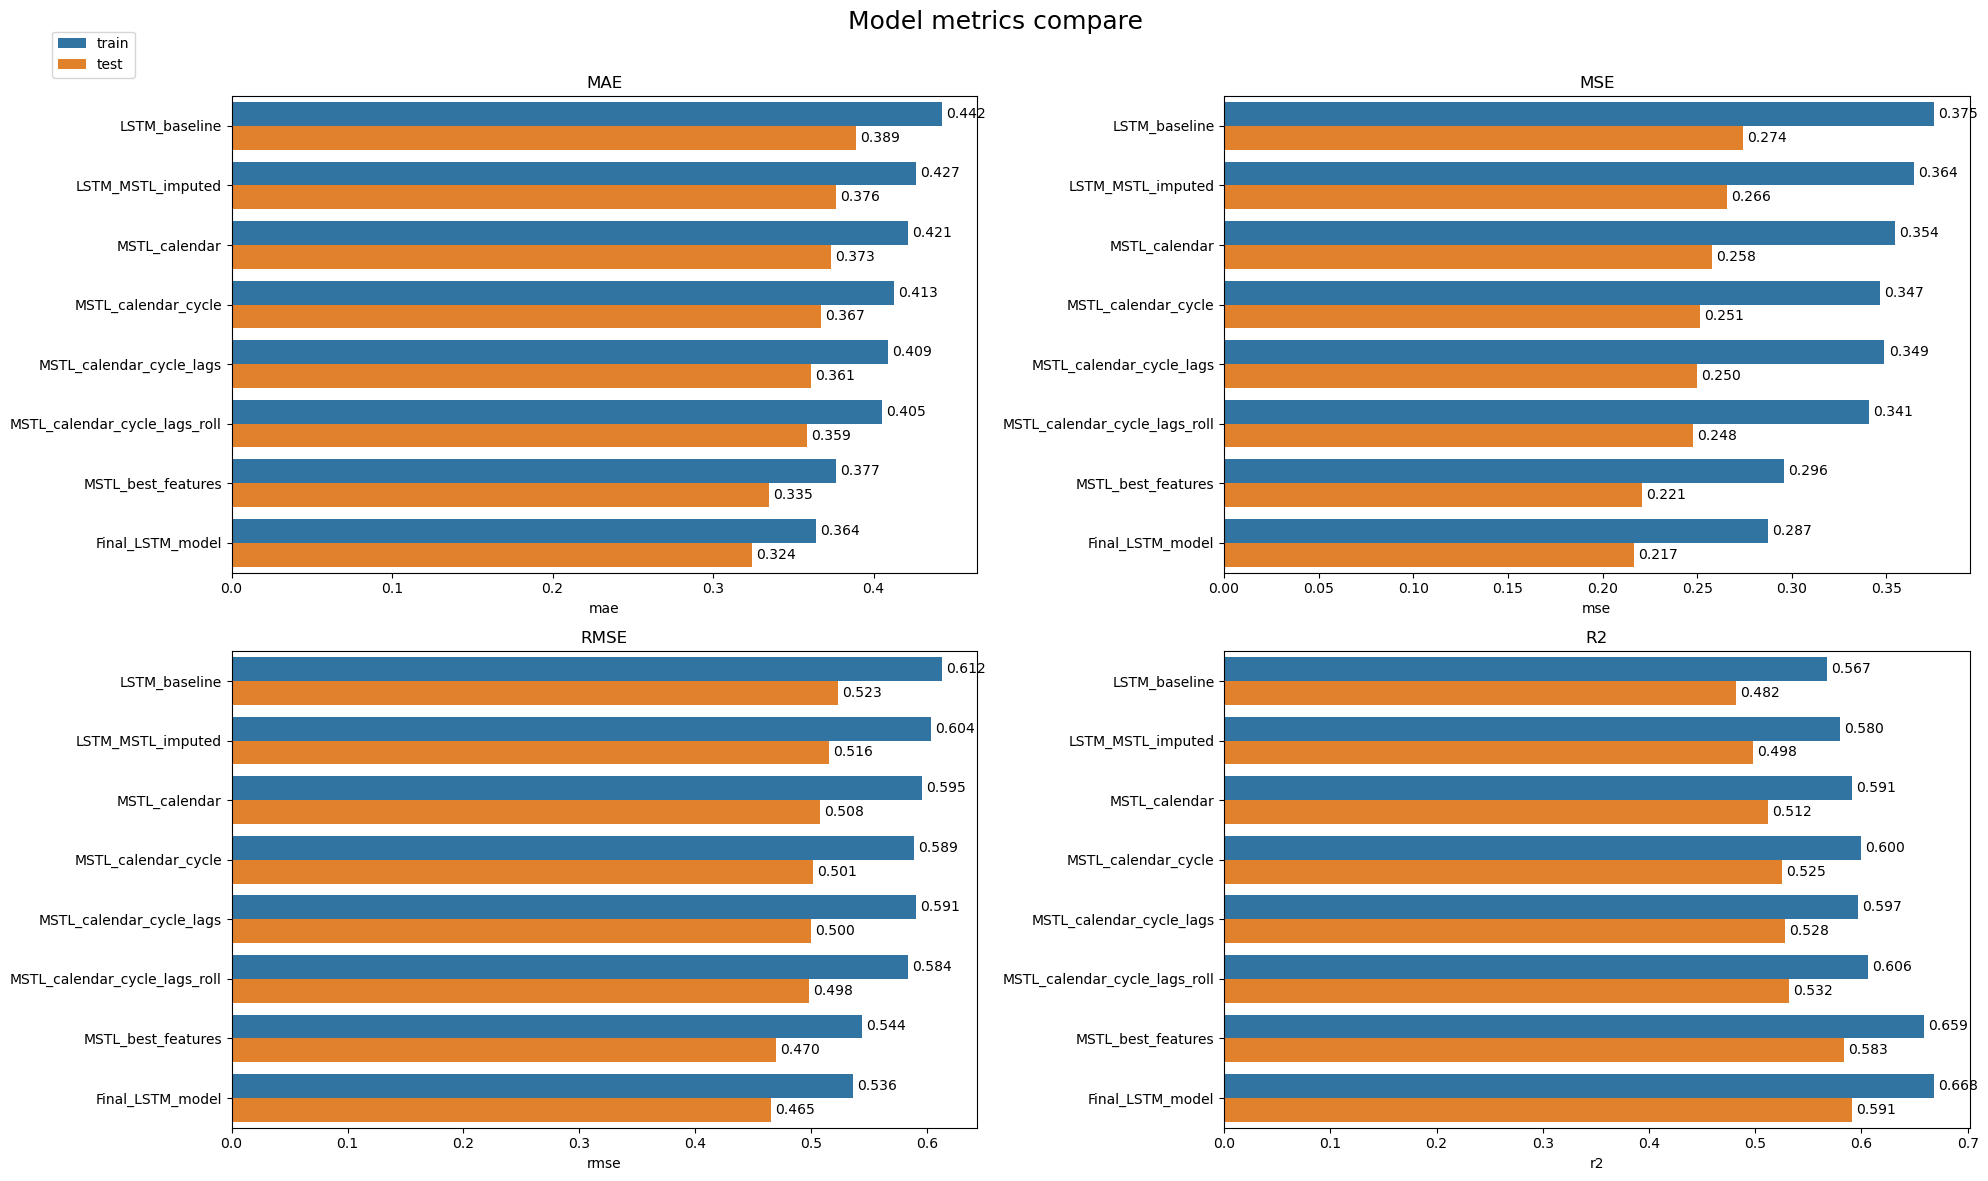

In [4]:
metrics = ["mae", "mse", "rmse", "r2"]

plt.figure(figsize=(20, 12))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    ax = sns.barplot(
        data=metrics_df,
        y="model_name",
        x=metric,
        hue="dataset",
        orient='h'
    )
    
    # Подписи значений
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3)

    plt.title(metric.upper())
    plt.ylabel("")

    if i == 1:
        plt.legend(loc="upper left", bbox_to_anchor=(-0.25, 1.15))
    else:
        plt.legend().remove()

plt.suptitle("Model metrics compare", fontsize=18)
plt.tight_layout()
plt.show()